# Training Frame Classifier (CNN, MobileNet, VGG19, Swin) pada NTHUDDD2_ROI

# Tujuan singkat:

Melatih dan membandingkan 4 model (CNN basic, MobileNetV3, VGG19, Swin) pada dataset ROI hasil ekstraksi MediaPipe.

Menggunakan normalisasi khusus NTHUDDD2 (mean/std dataset sendiri).

Untuk Swin, mengikuti konfigurasi jurnal: lr backbone kecil, lr head besar, Label Smoothing 0.1.

Menyimpan model terbaik (.pth) dan history (.json) untuk analisis serta tahap LSTM/Fuzzy berikutnya.

#  Import & konfigurasi

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import albumentations as A
import seaborn as sns
import json
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import gc
import torchvision.models as models
import timm


from IPython.display import display
from tqdm import tqdm
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

%matplotlib inline


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# --- KONFIGURASI PATH & DEVICE ---
DATASET_ROOT = r"C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

CLASS_NAMES = ["Open-Eyes", "Close-Eyes"]

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Dataset Root (ROI): {DATASET_ROOT}")


Device: cuda
Dataset Root (ROI): C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT


#  Pembacaan ROI & Utilitas Visualisasi

In [12]:
def load_and_preprocess(image_path):
    """
    Membaca gambar ROI (BGR) dari disk dan mengubah ke RGB.
    """
    bgr = cv2.imread(image_path)
    if bgr is None:
        return None

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb

def show_image_grid(images, titles=None, ncols=5, figsize=(15, 5)):
    n_images = len(images)
    nrows = int(np.ceil(n_images / ncols))
    plt.figure(figsize=figsize)
    for idx, img in enumerate(images):
        plt.subplot(nrows, ncols, idx + 1)
        plt.imshow(img)
        if titles and idx < len(titles):
            plt.title(titles[idx], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Augmentasi Albumentations (NTHUDDD2)

In [13]:

# Mean & Std NTHU
IMG_MEAN = [0.3772, 0.3772, 0.3772]
IMG_STD  = [0.1544, 0.1544, 0.1544]
IMG_SIZE  = 224

train_transform = A.Compose([
    # 1. GEOMETRIS
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, border_mode=cv2.BORDER_REFLECT, p=0.3),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.HorizontalFlip(p=0.5),

    # 2. REAL-WORLD DRIVING CONDITION (BLUR)
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.3),

    # 3. SENSOR / NOISE (DIBIARKAN DEFAULT AGAR AMAN DI VERSI 2.0.8)
    A.OneOf([
        A.GaussNoise(p=1.0),              # Otomatis menggunakan setting noise terbaik v2
        A.ImageCompression(p=1.0),        # Otomatis menggunakan rentang kompresi bawaan v2
    ], p=0.3),

    # 4. PSEUDO-SUBJECT: PENCAHAYAAN EKSTREM
    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
    ], p=0.6), 

    # 5. PSEUDO-SUBJECT: OCCLUSION / OBSTRUKSI (Sudah pakai API v2.0.8)
    A.CoarseDropout(
        num_holes_range=(4, 12),
        hole_height_range=(8, 24),
        hole_width_range=(8, 24),
        fill=0,
        p=0.4,
    ),

    # 6. FINALISASI
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

print("Augmentasi Ekstrem siap dan kompatibel dengan Albumentations v2.0.8 (NTHUDDD2).")


Augmentasi Ekstrem siap dan kompatibel dengan Albumentations v2.0.8 (NTHUDDD2).


# Custom Dataset (NTHUDDD2_ROI) dengan Pre-cleaning

In [14]:
class DrowsinessDataset(Dataset):
    def __init__(self, root_dir, transform=None, split_name="train"):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = CLASS_NAMES
        self.image_paths = []
        self.labels = []
        self.corrupted_files = []
        self.split_name = split_name

        for label, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                continue

            for fname in os.listdir(class_dir):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                fpath = os.path.join(class_dir, fname)
                img = cv2.imread(fpath)
                if img is None:
                    self.corrupted_files.append(fpath)
                    continue

                self.image_paths.append(fpath)
                self.labels.append(label)

        # Tulis log kalau ada file rusak
        if self.corrupted_files:
            log_dir = os.path.join(root_dir, "..", "logs")
            os.makedirs(log_dir, exist_ok=True)
            log_path = os.path.join(log_dir, f"corrupted_{self.split_name}.txt")
            with open(log_path, "w") as f:
                for p in self.corrupted_files:
                    f.write(p + "\n")
            print(f"[{self.split_name}] corrupted files: {len(self.corrupted_files)} (lihat {log_path})")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        img_rgb = load_and_preprocess(img_path)
        if img_rgb is None:
            # Guard terakhir: seharusnya jarang terjadi karena sudah pre-cleaning.
            raise RuntimeError(f"Gagal membaca gambar pada runtime: {img_path}")

        if self.transform:
            augmented = self.transform(image=img_rgb)
            img_tensor = augmented["image"]
        else:
            img_tensor = ToTensorV2()(image=img_rgb)["image"]

        return img_tensor, torch.tensor(label, dtype=torch.long)


# Inisialisasi DataLoader

In [15]:
train_dataset = DrowsinessDataset(TRAIN_DIR, transform=train_transform, split_name="train")
val_dataset   = DrowsinessDataset(VAL_DIR,   transform=val_test_transform, split_name="val")
test_dataset  = DrowsinessDataset(TEST_DIR,  transform=val_test_transform, split_name="test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")


Train samples: 67474
Val samples:   8776
Test samples:  8648


# train_model_pipeline

# Fungsi Training Master (Configurable Loss & Optimizer)

In [16]:
BASE_SAVE_DIR = "models_saved_data_MRL"
os.makedirs(BASE_SAVE_DIR, exist_ok=True)

def train_model_pipeline(
    model,
    model_name,
    train_loader,
    val_loader,
    device,
    epochs=EPOCHS,
    patience=5,
    criterion=None,
    optimizer=None,
    scheduler=None,
):
    model_name_upper = model_name.upper()
    model_dir = os.path.join(BASE_SAVE_DIR, model_name_upper)
    os.makedirs(model_dir, exist_ok=True)

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    if optimizer is None:
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

    if scheduler is None:
        scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0
    start_epoch = 0

    last_checkpoint_path = os.path.join(model_dir, f"{model_name_upper}_LAST.pth")
    if os.path.exists(last_checkpoint_path):
        print(f"Menemukan Checkpoint Lama! Melanjutkan training {model_name_upper}...")
        checkpoint = torch.load(last_checkpoint_path, map_location=device)

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        history = checkpoint["history"]
        best_val_loss = checkpoint.get("best_val_loss", float("inf"))
        epochs_no_improve = checkpoint.get("epochs_no_improve", 0)

        print(f"  Resume dari Epoch {start_epoch+1}")
        print(f"  Best Val Loss: {best_val_loss:.4f} | Strike: {epochs_no_improve}/{patience}")
    else:
        print(f"\nMEMULAI TRAINING BARU: {model_name_upper} (Max Epochs: {epochs})")

    for epoch in range(start_epoch, epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion)

        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{model_name_upper}] Epoch {epoch+1:02d}/{epochs:02d} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Train Acc: {train_acc:.2f}%"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_path = os.path.join(model_dir, f"{model_name_upper}_BEST.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"    Best model updated! (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"    No improvement for {epochs_no_improve} epoch(s).")

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "best_val_loss": best_val_loss,
                "epochs_no_improve": epochs_no_improve,
            },
            last_checkpoint_path,
        )

        if epochs_no_improve >= patience:
            print(f"\nEARLY STOPPING di Epoch {epoch+1}!")
            break

    history_path = os.path.join(model_dir, f"{model_name_upper}_history.json")
    with open(history_path, "w") as f:
        json.dump(history, f)

    print(f"\nTRAINING {model_name_upper} SELESAI. File tersimpan di: {model_dir}/")
    return model


# Config per‑model + helper untuk optimizer & loss

# Konfigurasi Per‑Model & Optimizer/Loss

In [17]:
MODEL_CONFIG = {
    "cnn_basic": {
        "epochs": 30,
        "patience": 5,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "loss": "ce",
    },
    "mobilenet": {
        "epochs": 30,
        "patience": 5,
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "loss": "ce",
    },
    "vgg19": {
        "epochs": 30,
        "patience": 5,
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "loss": "ce",
    },
    "swin": {
        "epochs": 30,
        "patience": 5,
        "lr_backbone": 1e-5,  
        "lr_head": 1e-3,
        "weight_decay": 1e-4,
        "loss": "label_smoothing",
        "label_smoothing": 0.1,
    },
}

def get_training_components(model, model_name):
    cfg = MODEL_CONFIG[model_name]

    if model_name == "swin":
        backbone_params = []
        head_params = []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if "backbone" in name:
                backbone_params.append(param)
            else:
                head_params.append(param)

        optimizer = optim.AdamW(
            [
                {"params": backbone_params, "lr": cfg["lr_backbone"]},
                {"params": head_params, "lr": cfg["lr_head"]},
            ],
            weight_decay=cfg["weight_decay"],
        )
        criterion = nn.CrossEntropyLoss(label_smoothing=cfg["label_smoothing"])
        scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    else:
        optimizer = optim.AdamW(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"],
        )
        if cfg["loss"] == "ce":
            criterion = nn.CrossEntropyLoss()
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=cfg.get("label_smoothing", 0.0))

        scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    return criterion, optimizer, scheduler, cfg


# FUNGSI TRAIN & VALIDATE PER EPOCH

In [18]:
# ==========================================
# FUNGSI TRAIN & VALIDATE PER EPOCH (+ MIXUP)
# ==========================================
import numpy as np
import torch
import random

# --- FUNGSI HELPER MIXUP ---
def mixup_data(x, y, alpha=0.2, use_cuda=True):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    if use_cuda:
        index = torch.randperm(batch_size).cuda()
    else:
        index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)
# ---------------------------

def train_epoch(model, loader, criterion, optimizer):
    """Satu putaran penuh training di seluruh data train dengan MixUp."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    MIXUP_PROB = 0.5 # Probabilitas 50% batch akan dicampur

    loop = tqdm(loader, desc='Training', leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # --- LOGIKA MIXUP ---
        use_mixup = random.random() < MIXUP_PROB
        
        if use_mixup:
            mixed_images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, use_cuda=True)
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            if lam > 0.5:
                correct += predicted.eq(targets_a).sum().item()
            else:
                correct += predicted.eq(targets_b).sum().item()
        else:
            # --- TRAINING NORMAL ---
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader), 100.0 * correct / total

def validate_epoch(model, loader, criterion):
    """Satu putaran penuh evaluasi di seluruh data validasi."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        loop = tqdm(loader, desc='Validating', leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100.0 * correct / total

print("Fungsi train_epoch (dengan MixUp) dan validate_epoch berhasil dimuat ke memori!")


Fungsi train_epoch (dengan MixUp) dan validate_epoch berhasil dimuat ke memori!


#  DEFINISI ARSITEKTUR MODEL 

In [19]:
# 1. CNN BASIC (Sanity Check / Baseline Terlemah)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        # --- PERBAIKAN: Global Average Pooling (Resolusi berapapun aman) ---
        self.gap = nn.AdaptiveAvgPool2d((1, 1))  
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512), # <-- Jauh lebih efisien, hanya 128 input neuron!
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# 2. MOBILENET V3 SMALL (REVISI: Hapus inplace=True)
class MobileNetDrowsiness(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(MobileNetDrowsiness, self).__init__()
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        self.model = models.mobilenet_v3_small(weights=weights)
        
        # Ambil jumlah fitur output dari Global Average Pooling MobileNet (576 fitur)
        n_features = self.model.classifier[0].in_features 
        
        # PENGGAL KEPALA BAWAAN & GANTI DENGAN KEPALA "FAIR 512"
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),            # <-- Hapus inplace=True
            nn.Linear(n_features, 512),
            nn.ReLU(),                    # <-- Hapus inplace=True
            nn.Dropout(p=0.3),            # <-- Hapus inplace=True
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)

# 3. VGG19_BN (REVISI: Hapus inplace=True)
class VGG19Drowsiness(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(VGG19Drowsiness, self).__init__()
        weights = models.VGG19_BN_Weights.DEFAULT if pretrained else None
        self.model = models.vgg19_bn(weights=weights)
        
        # Ambil jumlah fitur sebelum masuk ke classifier bawaan VGG (512 * 7 * 7 = 25088)
        n_features = self.model.classifier[0].in_features
        
        # PENGGAL 2 LAYER 4096 BAWAAN & GANTI DENGAN KEPALA "FAIR 512"
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),            # <-- Hapus inplace=True
            nn.Linear(n_features, 512),
            nn.ReLU(),                    # <-- Hapus inplace=True
            nn.Dropout(p=0.3),            # <-- Hapus inplace=True
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)


# 4. SWIN TRANSFORMER (Bintang Utama)
class SwinDrowsiness(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(SwinDrowsiness, self).__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=pretrained, num_classes=0)
        n_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)       
        output = self.classifier(features)
        return output

# --- FUNGSI PEMANGGIL MODEL ---
def get_model(model_name):
    if model_name == 'cnn_basic':
        return SimpleCNN()
    elif model_name == 'mobilenet':
        return MobileNetDrowsiness()
    elif model_name == 'vgg19':
        return VGG19Drowsiness()
    elif model_name == 'swin':
        return SwinDrowsiness()
    else:
        raise ValueError(f"Model {model_name} tidak ditemukan!")

print(" Arsitektur Model dan fungsi 'get_model' berhasil dimuat ke memori!")


 Arsitektur Model dan fungsi 'get_model' berhasil dimuat ke memori!


#  Blok training per model 

# CNN


In [20]:
# === TRAINING CNN BASIC ===
model_name = "cnn_basic"
print(f"\nMENYIAPKAN MODEL: {model_name.upper()}...")
model_cnn = get_model(model_name).to(device)

criterion, optimizer, scheduler, cfg = get_training_components(model_cnn, model_name)

model_cnn = train_model_pipeline(
    model=model_cnn,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=cfg["epochs"],
    patience=cfg["patience"],
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
)

print("\nMembersihkan memori GPU...")
del model_cnn
gc.collect()
torch.cuda.empty_cache()



MENYIAPKAN MODEL: CNN_BASIC...

MEMULAI TRAINING BARU: CNN_BASIC (Max Epochs: 30)


[CNN_BASIC] Epoch 01/30 | Val Loss: 0.6245 | Val Acc: 63.30% | Train Acc: 59.43%
    Best model updated! (Val Loss: 0.6245)


[CNN_BASIC] Epoch 02/30 | Val Loss: 0.6464 | Val Acc: 62.31% | Train Acc: 64.76%
    No improvement for 1 epoch(s).


[CNN_BASIC] Epoch 03/30 | Val Loss: 0.5916 | Val Acc: 74.54% | Train Acc: 71.54%
    Best model updated! (Val Loss: 0.5916)


[CNN_BASIC] Epoch 04/30 | Val Loss: 0.4627 | Val Acc: 78.71% | Train Acc: 77.59%
    Best model updated! (Val Loss: 0.4627)


...

[CNN_BASIC] Epoch 09/30 | Val Loss: 0.3956 | Val Acc: 81.84% | Train Acc: 82.34%
    No improvement for 1 epoch(s).


[CNN_BASIC] Epoch 10/30 | Val Loss: 0.3808 | Val Acc: 83.33% | Train Acc: 83.22%
    No improvement for 2 epoch(s).


[CNN_BASIC] Epoch 11/30 | Val Loss: 0.3353 | Val Acc: 85.06% | Train Acc: 83.62%
    No improvement for 3 epoch(s).


[CNN_BASIC] Epoch 12/30 | Val Loss: 0.3344 | Val Acc: 85.88% | Train Acc: 85.01%
    No improvement for 4 epoch(s).


[CNN_BASIC] Epoch 13/30 | Val Loss: 0.4262 | Val Acc: 80.57% | Train Acc: 85.55%
    No improvement for 5 epoch(s).

EARLY STOPPING di Epoch 13!

TRAINING CNN_BASIC SELESAI. File tersimpan di: models_saved_data_MRL\CNN_BASIC/

Membersihkan memori GPU...


# Training MobileNetV3 Small

In [21]:
# === TRAINING MOBILENET V3 SMALL ===


model_name = "mobilenet"
print(f"\nMENYIAPKAN MODEL: {model_name.upper()}...")

# 1. Bangun arsitektur
model_mobilenet = get_model(model_name).to(device)

# 2. Ambil loss, optimizer, scheduler, dan config khusus MobileNet
criterion, optimizer, scheduler, cfg = get_training_components(model_mobilenet, model_name)

# 3. Jalankan pipeline training
model_mobilenet = train_model_pipeline(
    model=model_mobilenet,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=cfg["epochs"],
    patience=cfg["patience"],
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
)

# 4. Bersihkan GPU
print("\nMembersihkan memori GPU...")
del model_mobilenet
gc.collect()
torch.cuda.empty_cache()
print("Memori GPU bersih! (MobileNet selesai)")



MENYIAPKAN MODEL: MOBILENET...

MEMULAI TRAINING BARU: MOBILENET (Max Epochs: 30)


[MOBILENET] Epoch 01/30 | Val Loss: 0.0971 | Val Acc: 96.78% | Train Acc: 91.30%
    Best model updated! (Val Loss: 0.0971)


[MOBILENET] Epoch 02/30 | Val Loss: 0.1007 | Val Acc: 97.35% | Train Acc: 95.00%
    No improvement for 1 epoch(s).


[MOBILENET] Epoch 03/30 | Val Loss: 0.1039 | Val Acc: 96.56% | Train Acc: 95.48%
    No improvement for 2 epoch(s).


[MOBILENET] Epoch 04/30 | Val Loss: 0.0758 | Val Acc: 97.56% | Train Acc: 95.88%
    Best model updated! (Val Loss: 0.0758)


...

[MOBILENET] Epoch 07/30 | Val Loss: 0.0774 | Val Acc: 97.48% | Train Acc: 96.31%
    No improvement for 1 epoch(s).


[MOBILENET] Epoch 08/30 | Val Loss: 0.0879 | Val Acc: 96.82% | Train Acc: 96.57%
    No improvement for 2 epoch(s).


[MOBILENET] Epoch 09/30 | Val Loss: 0.0956 | Val Acc: 97.05% | Train Acc: 96.79%
    No improvement for 3 epoch(s).


[MOBILENET] Epoch 10/30 | Val Loss: 0.0848 | Val Acc: 97.19% | Train Acc: 96.91%
    No improvement for 4 epoch(s).


[MOBILENET] Epoch 11/30 | Val Loss: 0.0862 | Val Acc: 97.00% | Train Acc: 96.94%
    No improvement for 5 epoch(s).

EARLY STOPPING di Epoch 11!

TRAINING MOBILENET SELESAI. File tersimpan di: models_saved_data_MRL\MOBILENET/

Membersihkan memori GPU...
Memori GPU bersih! (MobileNet selesai)


#  Training VGG19_BN

In [22]:
# === TRAINING VGG19_BN ===

model_name = "vgg19"
print(f"\nMENYIAPKAN MODEL: {model_name.upper()}...")

model_vgg = get_model(model_name).to(device)

criterion, optimizer, scheduler, cfg = get_training_components(model_vgg, model_name)

model_vgg = train_model_pipeline(
    model=model_vgg,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=cfg["epochs"],
    patience=cfg["patience"],
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
)

print("\nMembersihkan memori GPU...")
del model_vgg
gc.collect()
torch.cuda.empty_cache()
print("Memori GPU bersih! (VGG19 selesai)")



MENYIAPKAN MODEL: VGG19...

MEMULAI TRAINING BARU: VGG19 (Max Epochs: 30)


[VGG19] Epoch 01/30 | Val Loss: 0.0920 | Val Acc: 97.05% | Train Acc: 93.87%
    Best model updated! (Val Loss: 0.0920)


[VGG19] Epoch 02/30 | Val Loss: 0.0913 | Val Acc: 97.22% | Train Acc: 95.83%
    Best model updated! (Val Loss: 0.0913)


[VGG19] Epoch 03/30 | Val Loss: 0.0804 | Val Acc: 97.71% | Train Acc: 95.90%
    Best model updated! (Val Loss: 0.0804)


[VGG19] Epoch 04/30 | Val Loss: 0.0880 | Val Acc: 97.31% | Train Acc: 96.12%
    No improvement for 1 epoch(s).


...

[VGG19] Epoch 12/30 | Val Loss: 0.0911 | Val Acc: 97.20% | Train Acc: 97.20%
    No improvement for 1 epoch(s).


[VGG19] Epoch 13/30 | Val Loss: 0.0862 | Val Acc: 97.45% | Train Acc: 97.34%
    No improvement for 2 epoch(s).


[VGG19] Epoch 14/30 | Val Loss: 0.0809 | Val Acc: 97.07% | Train Acc: 97.47%
    No improvement for 3 epoch(s).


[VGG19] Epoch 15/30 | Val Loss: 0.0947 | Val Acc: 96.75% | Train Acc: 97.74%
    No improvement for 4 epoch(s).


[VGG19] Epoch 16/30 | Val Loss: 0.1037 | Val Acc: 96.82% | Train Acc: 97.50%
    No improvement for 5 epoch(s).

EARLY STOPPING di Epoch 16!

TRAINING VGG19 SELESAI. File tersimpan di: models_saved_data_MRL\VGG19/

Membersihkan memori GPU...
Memori GPU bersih! (VGG19 selesai)


# Training Swin Transformer

In [23]:
# === TRAINING SWIN TRANSFORMER (PROPOSED) ===

model_name = "swin"
print(f"\nMENYIAPKAN MODEL: {model_name.upper()}...")

model_swin = get_model(model_name).to(device)

criterion, optimizer, scheduler, cfg = get_training_components(model_swin, model_name)

model_swin = train_model_pipeline(
    model=model_swin,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=cfg["epochs"],
    patience=cfg["patience"],
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
)

print("\nMembersihkan memori GPU...")
del model_swin
gc.collect()
torch.cuda.empty_cache()
print("Memori GPU bersih! (Swin selesai)")



MENYIAPKAN MODEL: SWIN...

MEMULAI TRAINING BARU: SWIN (Max Epochs: 30)


[SWIN] Epoch 01/30 | Val Loss: 0.2411 | Val Acc: 97.58% | Train Acc: 92.71%
    Best model updated! (Val Loss: 0.2411)


[SWIN] Epoch 02/30 | Val Loss: 0.2398 | Val Acc: 97.73% | Train Acc: 95.18%
    Best model updated! (Val Loss: 0.2398)


[SWIN] Epoch 03/30 | Val Loss: 0.2499 | Val Acc: 97.08% | Train Acc: 95.89%
    No improvement for 1 epoch(s).


[SWIN] Epoch 04/30 | Val Loss: 0.2414 | Val Acc: 97.48% | Train Acc: 96.04%
    No improvement for 2 epoch(s).


...

[SWIN] Epoch 08/30 | Val Loss: 0.2417 | Val Acc: 97.42% | Train Acc: 96.78%
    No improvement for 1 epoch(s).


[SWIN] Epoch 09/30 | Val Loss: 0.2410 | Val Acc: 97.56% | Train Acc: 96.65%
    No improvement for 2 epoch(s).


[SWIN] Epoch 10/30 | Val Loss: 0.2468 | Val Acc: 97.28% | Train Acc: 96.90%
    No improvement for 3 epoch(s).


[SWIN] Epoch 11/30 | Val Loss: 0.2403 | Val Acc: 97.69% | Train Acc: 97.06%
    No improvement for 4 epoch(s).


[SWIN] Epoch 12/30 | Val Loss: 0.2468 | Val Acc: 97.12% | Train Acc: 97.02%
    No improvement for 5 epoch(s).

EARLY STOPPING di Epoch 12!

TRAINING SWIN SELESAI. File tersimpan di: models_saved_data_MRL\SWIN/

Membersihkan memori GPU...
Memori GPU bersih! (Swin selesai)


# Visualisasi & Evaluasi


 MENGGAMBAR KURVA PERBANDINGAN TRAINING...


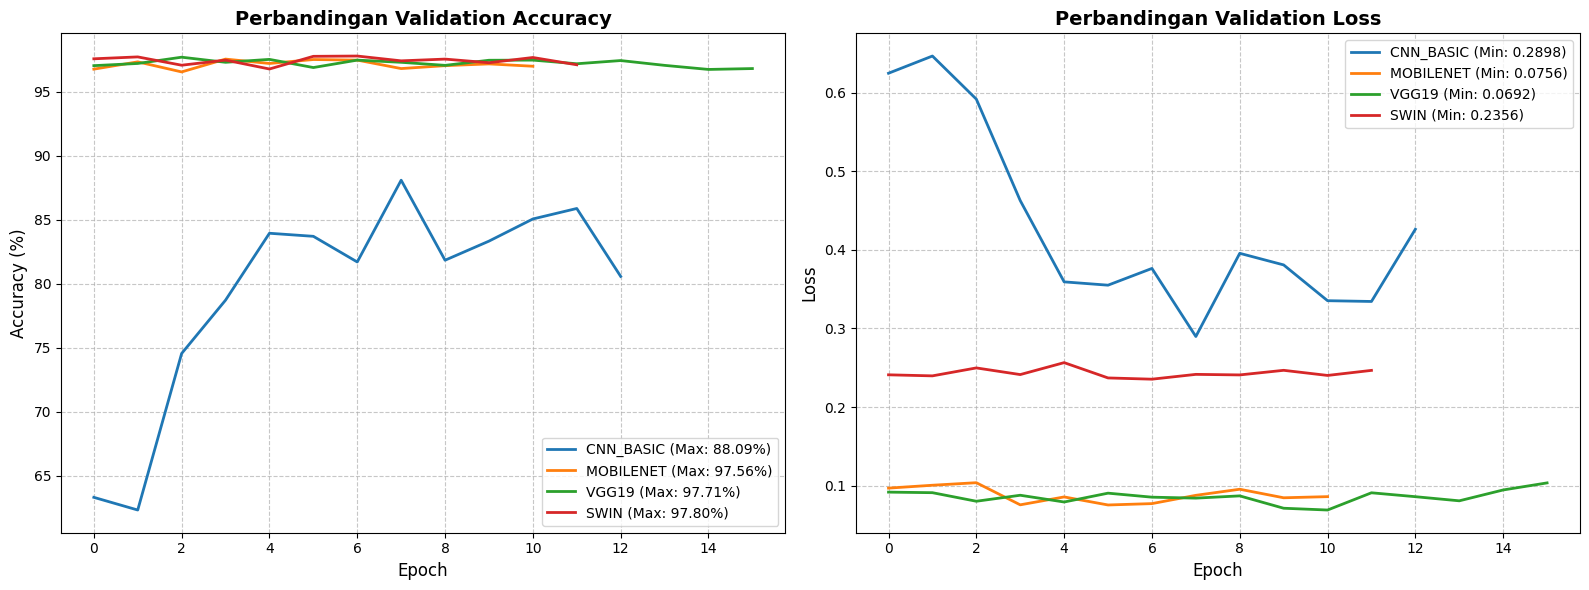

\n MEMULAI UJIAN BLIND-TEST PADA TEST SET...
   Melakukan testing untuk model: CNN_BASIC...


   Melakukan testing untuk model: MOBILENET...


   Melakukan testing untuk model: VGG19...


   Melakukan testing untuk model: SWIN...


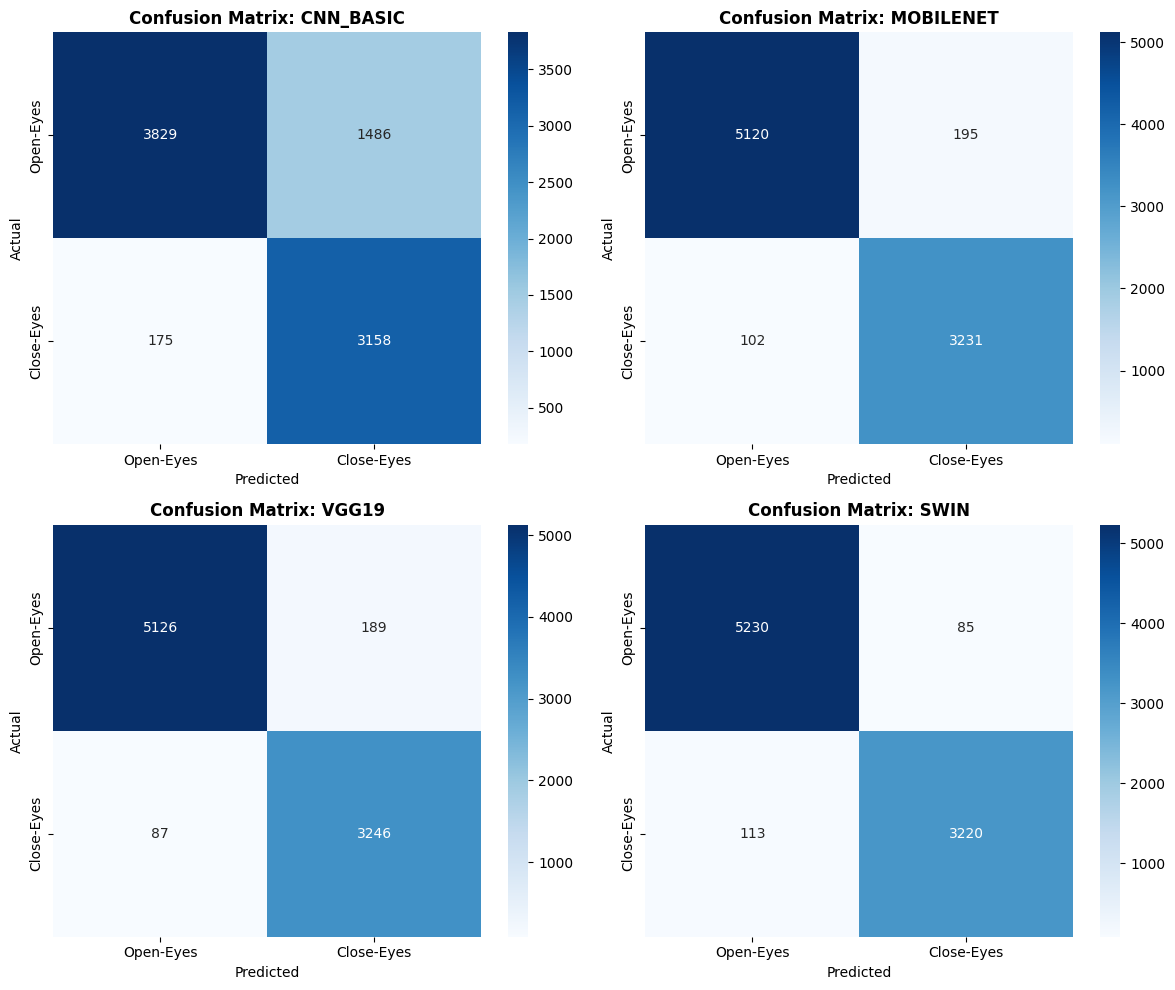


 TABEL REKAPITULASI PERFORMA MODEL (Data Uji Baru NTHUDDD2):


,Model,Accuracy (%),Precision,Recall,F1-Score
0,SWIN,97.71,97.66,97.51,97.58
1,VGG19,96.81,96.41,96.92,96.65
2,MOBILENET,96.57,96.18,96.64,96.39
3,CNN_BASIC,80.79,81.82,83.40,80.68



 MEMULAI ANALISIS EFISIENSI KOMPUTASI (Inference Time & Parameters)...



 TABEL EFISIENSI KOMPUTASI (Penting untuk Analisis Real-Time):


,Model,Params (M),Inf. Time (ms/frame),Max FPS
0,CNN_BASIC,0.16,0.80,1254
1,MOBILENET,1.22,6.62,151
2,VGG19,32.88,6.96,143
3,SWIN,27.91,13.63,73



 TABEL REKAPITULASI FINAL (Performa + Efisiensi):


,Model,Accuracy (%),Precision,Recall,F1-Score,Params (M),Inf. Time (ms/frame),Max FPS
0,SWIN,97.71,97.66,97.51,97.58,27.91,13.63,73
1,VGG19,96.81,96.41,96.92,96.65,32.88,6.96,143
2,MOBILENET,96.57,96.18,96.64,96.39,1.22,6.62,151
3,CNN_BASIC,80.79,81.82,83.40,80.68,0.16,0.80,1254


In [24]:
# =========================================================================
# 10. EVALUASI DAN VISUALISASI MODEL (BLIND-TEST)
# =========================================================================

# Pastikan variabel ini sama dengan nama folder yang dibuat oleh fungsi training
BASE_SAVE_DIR = "models_saved_data_MRL"

# Tuple berisi: (Nama_Folder, Key_di_Fungsi_get_model)
models_to_evaluate = [
    ('CNN_BASIC', 'cnn_basic'), 
    ('MOBILENET', 'mobilenet'), 
    ('VGG19', 'vgg19'), 
    ('SWIN', 'swin')
]

# Setel class names untuk MRL (Open-Eyes vs Close-Eyes)
CLASS_NAMES = ["Open-Eyes", "Close-Eyes"]

# =========================================================================
# BAGIAN A: PLOT KURVA TRAINING (DARI FILE JSON)
# =========================================================================
print("\n MENGGAMBAR KURVA PERBANDINGAN TRAINING...")
plt.figure(figsize=(16, 6))

# Subplot 1: Validation Accuracy
plt.subplot(1, 2, 1)
for folder_name, _ in models_to_evaluate:
    json_path = os.path.join(BASE_SAVE_DIR, folder_name, f"{folder_name}_history.json")
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            history = json.load(f)
            # Plot akurasi. Jika model berhenti lebih awal (early stopping), garisnya akan lebih pendek.
            plt.plot(history['val_acc'], label=f"{folder_name} (Max: {max(history['val_acc']):.2f}%)", linewidth=2)
            
plt.title("Perbandingan Validation Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Validation Loss
plt.subplot(1, 2, 2)
for folder_name, _ in models_to_evaluate:
    json_path = os.path.join(BASE_SAVE_DIR, folder_name, f"{folder_name}_history.json")
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            history = json.load(f)
            plt.plot(history['val_loss'], label=f"{folder_name} (Min: {min(history['val_loss']):.4f})", linewidth=2)
            
plt.title("Perbandingan Validation Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# =========================================================================
# BAGIAN B: UJIAN BLIND-TEST MENGGUNAKAN DATA TEST (DARI FILE _BEST.pth)
# =========================================================================
print("\\n MEMULAI UJIAN BLIND-TEST PADA TEST SET...")

results_data = []

# Siapkan Matriks 2x2 untuk Plotting Confusion Matrix ke-4 model
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (folder_name, model_key) in enumerate(models_to_evaluate):
    best_pth_path = os.path.join(BASE_SAVE_DIR, folder_name, f"{folder_name}_BEST.pth")
    
    if not os.path.exists(best_pth_path):
        print(f" Melewati {folder_name} (File _BEST.pth tidak ditemukan)")
        continue
        
    print(f"   Melakukan testing untuk model: {folder_name}...")
    
    # 1. Bangun Model & Load Bobot Terbaik
    model = get_model(model_key).to(device)
    # Gunakan map_location=device untuk keamanan jika dilatih di mesin berbeda
    model.load_state_dict(torch.load(best_pth_path, map_location=device))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    # 2. Proses Inferensi (Tanpa hitung gradient)
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {folder_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            # Pindahkan hasil ke CPU untuk Scikit-Learn
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 3. Hitung Metrik Skripsi (Macro average lebih adil jika ada slight imbalance)
    acc = accuracy_score(all_labels, all_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    
    results_data.append({
        'Model': folder_name,
        'Accuracy (%)': round(acc, 2),
        'Precision': round(precision * 100, 2), # Jadikan persentase agar seragam
        'Recall': round(recall * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    })
    
    # 4. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[idx].set_title(f"Confusion Matrix: {folder_name}", fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    
    # 5. Bersihkan Memori GPU
    del model
    torch.cuda.empty_cache()

plt.tight_layout()
plt.show()

# =========================================================================
# BAGIAN C: TABEL REKAPITULASI (TABEL MAHKOTA BAB 4)
# =========================================================================
print("\n TABEL REKAPITULASI PERFORMA MODEL (Data Uji Baru NTHUDDD2):")
if results_data:
    df_results = pd.DataFrame(results_data)
    # Sortir berdasarkan Accuracy tertinggi
    df_results = df_results.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)
    display(df_results)
else:
    print("Tidak ada hasil evaluasi yang tersedia.")

# =========================================================================
# BAGIAN D: ANALISIS EFISIENSI KOMPUTASI (PARAMETER & INFERENCE TIME)
# =========================================================================
import time
from thop import profile # Jika error, install via: !pip install thop

print("\n MEMULAI ANALISIS EFISIENSI KOMPUTASI (Inference Time & Parameters)...")

efficiency_data = []

# Buat dummy tensor 1 gambar untuk ngetes kecepatan (batch size = 1 untuk simulasi real-time webcam)
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

for folder_name, model_key in models_to_evaluate:
    best_pth_path = os.path.join(BASE_SAVE_DIR, folder_name, f"{folder_name}_BEST.pth")
    if not os.path.exists(best_pth_path):
        continue
        
    model = get_model(model_key).to(device)
    model.load_state_dict(torch.load(best_pth_path, map_location=device))
    model.eval()
    
    # 1. Hitung Jumlah Parameter (dalam Juta / Millions)
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    
    # 2. Pemanasan GPU (Warm-up) agar pengukuran waktu akurat
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)
            
    # 3. Hitung Waktu Inferensi per Frame (Simulasi Real-time)
    start_time = time.time()
    num_tests = 100
    with torch.no_grad():
        for _ in range(num_tests):
            _ = model(dummy_input)
    
    # Rata-rata waktu per frame dalam milidetik (ms)
    avg_inference_time_ms = ((time.time() - start_time) / num_tests) * 1000
    
    # Hitung FPS (Frames per Second) teoretis
    fps = 1000 / avg_inference_time_ms if avg_inference_time_ms > 0 else 0
    
    efficiency_data.append({
        'Model': folder_name,
        'Params (M)': round(total_params, 2),
        'Inf. Time (ms/frame)': round(avg_inference_time_ms, 2),
        'Max FPS': int(fps)
    })
    
    del model
    torch.cuda.empty_cache()

# Tampilkan Tabel Efisiensi Komputasi
if efficiency_data:
    df_efficiency = pd.DataFrame(efficiency_data)
    print("\n TABEL EFISIENSI KOMPUTASI (Penting untuk Analisis Real-Time):")
    display(df_efficiency)

# --- GABUNGKAN TABEL A & TABEL D (OPSIONAL UNTUK REKAP SKRIPSI) ---
if results_data and efficiency_data:
    df_final = pd.merge(df_results, df_efficiency, on='Model')
    print("\n TABEL REKAPITULASI FINAL (Performa + Efisiensi):")
    display(df_final)


